# Correlation × Concentration Sweep — Results

Plot results from `python -m simple.sweep`. Set `RESULTS_DIR` below.

In [1]:
import sys, os, json, pickle
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [ ]:
# ── Point to sweep results ──
RESULTS_DIR = "data/sweep_20260412_183831"

# Optionally launch from here:
# !python -m simple.sweep --out {RESULTS_DIR} --workers 20 --seeds 42 123 777

In [3]:
# ── Run config ──
rdir = Path(RESULTS_DIR)
with open(rdir / "config.json") as f:
    cfg = json.load(f)
print(json.dumps(cfg, indent=2))

{
  "n_a": 6,
  "n_burst": 6,
  "depth": 3,
  "burst_pos": 3,
  "n_docs": 100,
  "n_eval": 100,
  "correlations": [
    0.0,
    0.16666666666666666,
    0.3333333333333333,
    0.5,
    0.6666666666666666,
    0.8333333333333334,
    1.0
  ],
  "fracs": [
    1.0,
    0.95,
    0.9,
    0.7,
    0.5,
    0.3
  ],
  "seeds": [
    42,
    123,
    777
  ],
  "ft_steps": 2000,
  "fg_steps": 1200,
  "ft_lr": 0.0001,
  "fg_lr": 0.0001,
  "batch_size": 512,
  "eval_every": 100,
  "workers": 3,
  "out": "data/sweep_20260412_115007",
  "resume": false,
  "timestamp": "2026-04-12T11:50:07.168758"
}


In [4]:
# ── Load results ──
CORRELATIONS = cfg["correlations"]
FRACS = cfg["fracs"]
SEEDS = cfg["seeds"]
N_A = cfg["n_a"]
N_BURST = cfg["n_burst"]
n_corr, n_frac, n_seeds = len(CORRELATIONS), len(FRACS), len(SEEDS)

all_ft = {c: {} for c in CORRELATIONS}
all_fg = {c: {} for c in CORRELATIONS}
loaded, missing = 0, 0
for corr in CORRELATIONS:
    for seed in SEEDS:
        ft_list, fg_list = [], []
        for frac in FRACS:
            c = int(round(corr * 100))
            f = int(round(frac * 100))
            ft_p = rdir / f"seed_{seed}" / f"corr{c}_frac{f}_ft.pkl"
            fg_p = rdir / f"seed_{seed}" / f"corr{c}_frac{f}_fg.pkl"
            if ft_p.exists() and fg_p.exists():
                with open(ft_p, "rb") as fp: ft_list.append(pickle.load(fp))
                with open(fg_p, "rb") as fp: fg_list.append(pickle.load(fp))
                loaded += 1
            else:
                ft_list.append(None); fg_list.append(None); missing += 1
        all_ft[corr][seed] = ft_list
        all_fg[corr][seed] = fg_list
print(f"Loaded {loaded}/{loaded+missing} runs ({missing} missing)")

Loaded 126/126 runs (0 missing)


In [5]:
def _safe_last(log, key):
    v = log.get(key, [])
    return v[-1] if v else float("nan")

def _extract(corr, i_f, fn):
    vals = []
    for s in SEEDS:
        ft, fg = all_ft[corr][s][i_f], all_fg[corr][s][i_f]
        if ft is not None and fg is not None:
            vals.append(fn(ft, fg))
    return vals

metric_fns = {
    "peak_burst":          lambda ft, fg: ft["peak_burst"],
    "drop_pct":            lambda ft, fg: fg["dropoff_pct"],
    "reversion_auc":       lambda ft, fg: fg["reversion_auc"],
    "ft_bg_acc":           lambda ft, fg: ft["log"]["acc_other"][-1],
    "ft_bg_loss":          lambda ft, fg: ft["log"]["loss_other"][-1],
    "ft_burst_acc":        lambda ft, fg: ft["log"]["acc_burst"][-1],
    "fg_burst_acc":        lambda ft, fg: fg["log"]["acc_burst"][-1],
    "fg_bg_acc":           lambda ft, fg: fg["log"]["acc_other"][-1],
    "ft_burst_novel_acc":  lambda ft, fg: _safe_last(ft["log"], "acc_burst_novel"),
    "ft_burst_copied_acc": lambda ft, fg: _safe_last(ft["log"], "acc_burst_copied"),
    "fg_burst_novel_acc":  lambda ft, fg: _safe_last(fg["log"], "acc_burst_novel"),
    "fg_burst_copied_acc": lambda ft, fg: _safe_last(fg["log"], "acc_burst_copied"),
}

grids_mean, grids_std = {}, {}
for name, fn in metric_fns.items():
    mean = np.full((n_corr, n_frac), np.nan)
    std = np.full((n_corr, n_frac), np.nan)
    for i_c, corr in enumerate(CORRELATIONS):
        for i_f in range(n_frac):
            vals = _extract(corr, i_f, fn)
            if vals:
                mean[i_c, i_f] = np.nanmean(vals)
                std[i_c, i_f] = np.nanstd(vals)
    grids_mean[name] = mean
    grids_std[name] = std
print(f"Extracted {sum(1 for v in grids_mean['peak_burst'].flatten() if not np.isnan(v))}/{n_corr*n_frac} cells")

Extracted 42/42 cells


/tmp/ipykernel_2612126/3291851665.py:36: RuntimeWarning: Mean of empty slice
  mean[i_c, i_f] = np.nanmean(vals)
/workspace/compositional_capabilities_burst/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


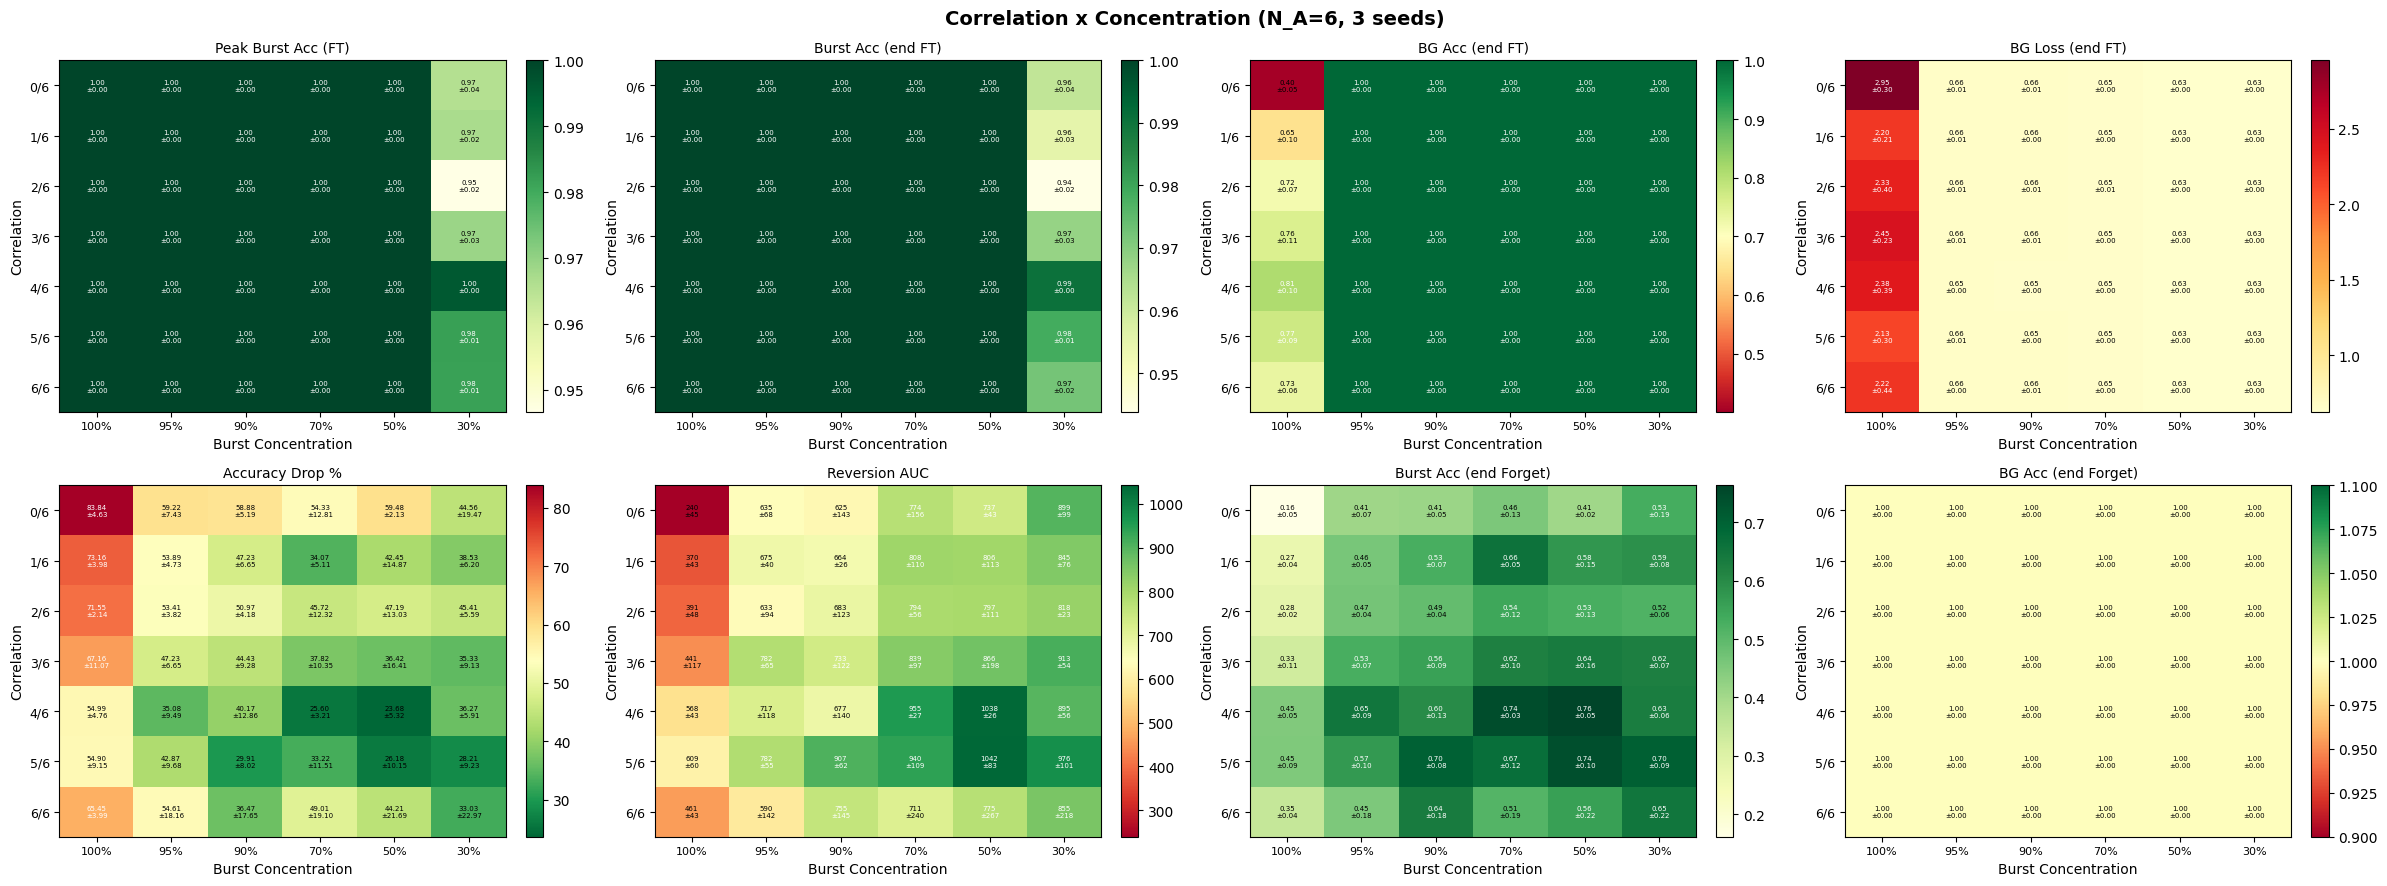

In [6]:
corr_labels = [f"{int(round(c*N_BURST))}/{N_BURST}" for c in CORRELATIONS]
frac_labels = [f"{int(f*100)}%" for f in FRACS]
heatmap_defs = [
    ("Peak Burst Acc (FT)", "peak_burst", "YlGn"),
    ("Burst Acc (end FT)", "ft_burst_acc", "YlGn"),
    ("BG Acc (end FT)", "ft_bg_acc", "RdYlGn"),
    ("BG Loss (end FT)", "ft_bg_loss", "YlOrRd"),
    ("Accuracy Drop %", "drop_pct", "RdYlGn_r"),
    ("Reversion AUC", "reversion_auc", "RdYlGn"),
    ("Burst Acc (end Forget)", "fg_burst_acc", "YlGn"),
    ("BG Acc (end Forget)", "fg_bg_acc", "RdYlGn"),
]
n_cols, n_rows = 4, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4.5*n_rows))
axes = axes.flatten()
for idx, (title, key, cmap) in enumerate(heatmap_defs):
    ax = axes[idx]; grid = grids_mean[key]
    im = ax.imshow(grid, aspect="auto", cmap=cmap)
    ax.set_xticks(range(n_frac)); ax.set_xticklabels(frac_labels, fontsize=8)
    ax.set_yticks(range(n_corr)); ax.set_yticklabels(corr_labels, fontsize=9)
    ax.set_xlabel("Burst Concentration"); ax.set_ylabel("Correlation")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(n_corr):
        for j in range(n_frac):
            m, s = grids_mean[key][i,j], grids_std[key][i,j]
            if np.isnan(m): continue
            txt = f"{m:.2f}\n\u00b1{s:.2f}" if abs(m)<100 else f"{m:.0f}\n\u00b1{s:.0f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=5,
                    color="white" if abs(m-np.nanmin(grid))>0.6*(np.nanmax(grid)-np.nanmin(grid)) else "black")
fig.suptitle(f"Correlation x Concentration (N_A={N_A}, {n_seeds} seeds)", fontsize=14, fontweight="bold")
fig.tight_layout(); plt.show()

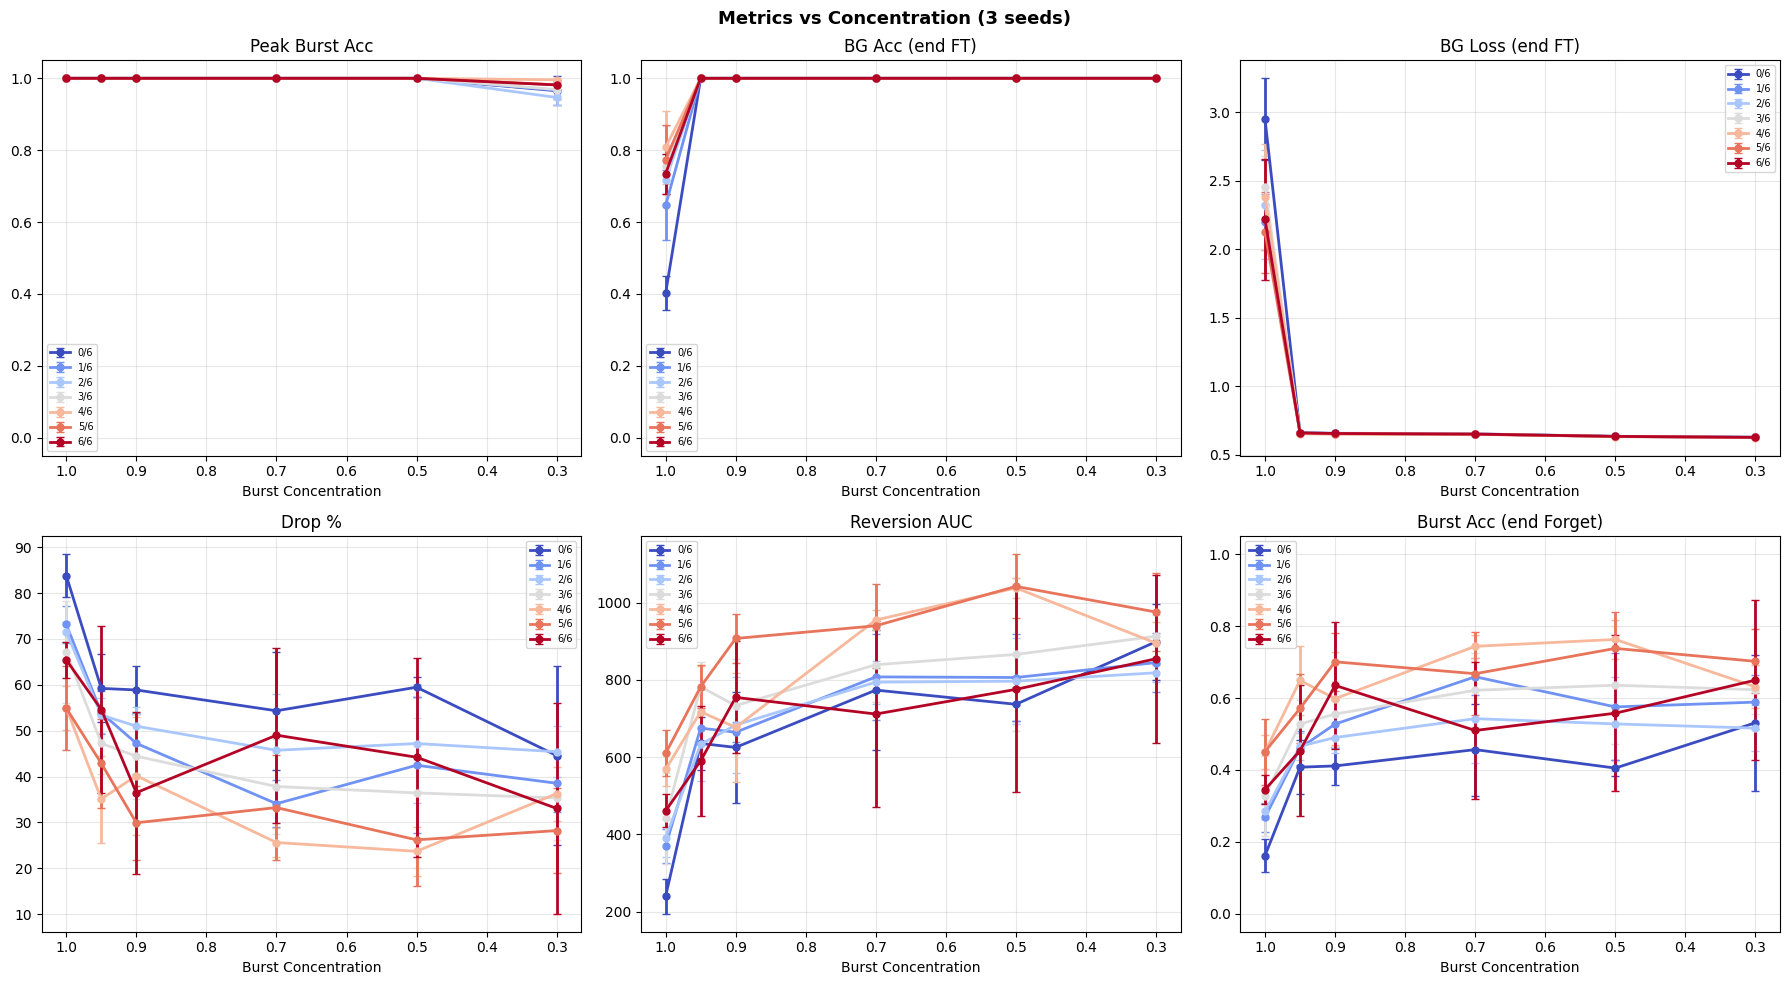

In [7]:
corr_colors = plt.cm.coolwarm(np.linspace(0, 1, n_corr))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [
    ("Peak Burst Acc", "peak_burst", axes[0,0], (-0.05, 1.05)),
    ("BG Acc (end FT)", "ft_bg_acc", axes[0,1], (-0.05, 1.05)),
    ("BG Loss (end FT)", "ft_bg_loss", axes[0,2], None),
    ("Drop %", "drop_pct", axes[1,0], None),
    ("Reversion AUC", "reversion_auc", axes[1,1], None),
    ("Burst Acc (end Forget)", "fg_burst_acc", axes[1,2], (-0.05, 1.05)),
]
for title, key, ax, ylim in metrics:
    for i_c, corr in enumerate(CORRELATIONS):
        n_cop = int(round(corr*N_BURST))
        m, s = grids_mean[key][i_c], grids_std[key][i_c]
        ax.errorbar(FRACS, m, yerr=s, fmt="o-", color=corr_colors[i_c],
                    label=f"{n_cop}/{N_BURST}", linewidth=2, markersize=5, capsize=3)
    ax.set_xlabel("Burst Concentration"); ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.invert_xaxis()
    if ylim: ax.set_ylim(*ylim)
fig.suptitle(f"Metrics vs Concentration ({n_seeds} seeds)", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

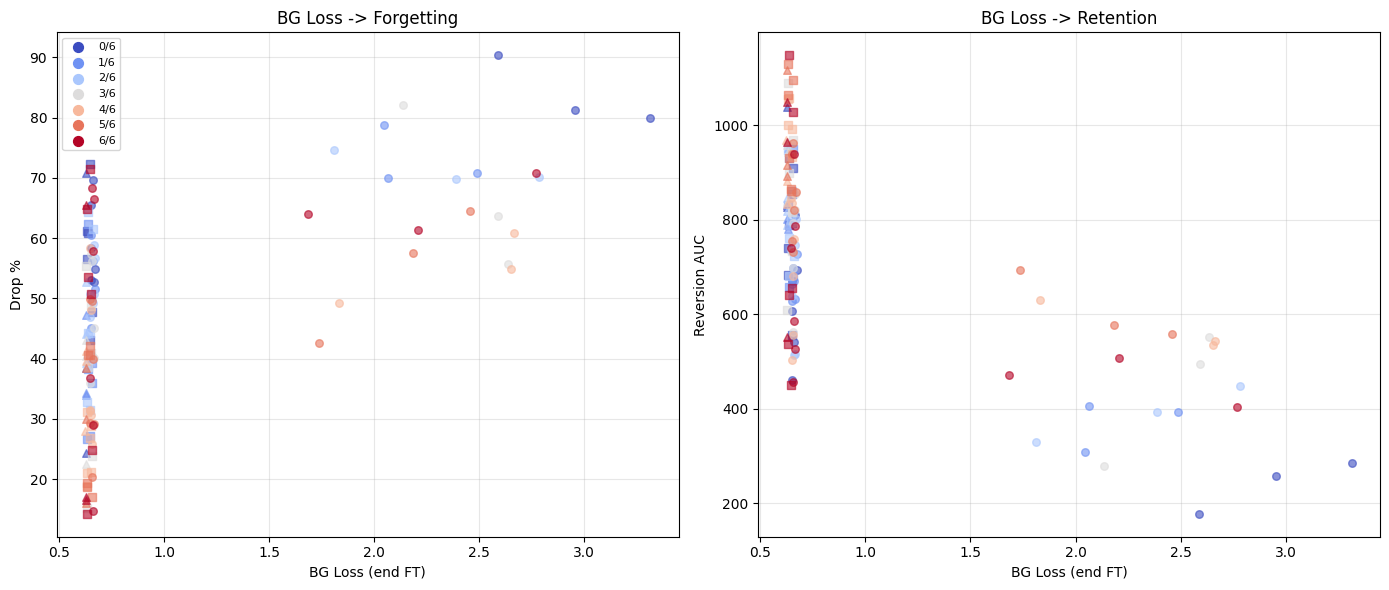

In [8]:
corr_colors = plt.cm.coolwarm(np.linspace(0, 1, n_corr))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for i_c, corr in enumerate(CORRELATIONS):
    color = corr_colors[i_c]
    for i_f, frac in enumerate(FRACS):
        for seed in SEEDS:
            ft_r, fg_r = all_ft[corr][seed][i_f], all_fg[corr][seed][i_f]
            if ft_r is None or fg_r is None: continue
            bg_loss = ft_r["log"]["loss_other"][-1]
            marker = "o" if frac>=0.9 else ("s" if frac>=0.5 else "^")
            ax1.scatter(bg_loss, fg_r["dropoff_pct"], c=[color], marker=marker, s=30, alpha=0.6, zorder=3)
            ax2.scatter(bg_loss, fg_r["reversion_auc"], c=[color], marker=marker, s=30, alpha=0.6, zorder=3)
for i_c, corr in enumerate(CORRELATIONS):
    n_cop = int(round(corr*N_BURST))
    ax1.scatter([], [], c=[corr_colors[i_c]], label=f"{n_cop}/{N_BURST}", s=50)
ax1.set_xlabel("BG Loss (end FT)"); ax1.set_ylabel("Drop %")
ax1.set_title("BG Loss -> Forgetting"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("BG Loss (end FT)"); ax2.set_ylabel("Reversion AUC")
ax2.set_title("BG Loss -> Retention"); ax2.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

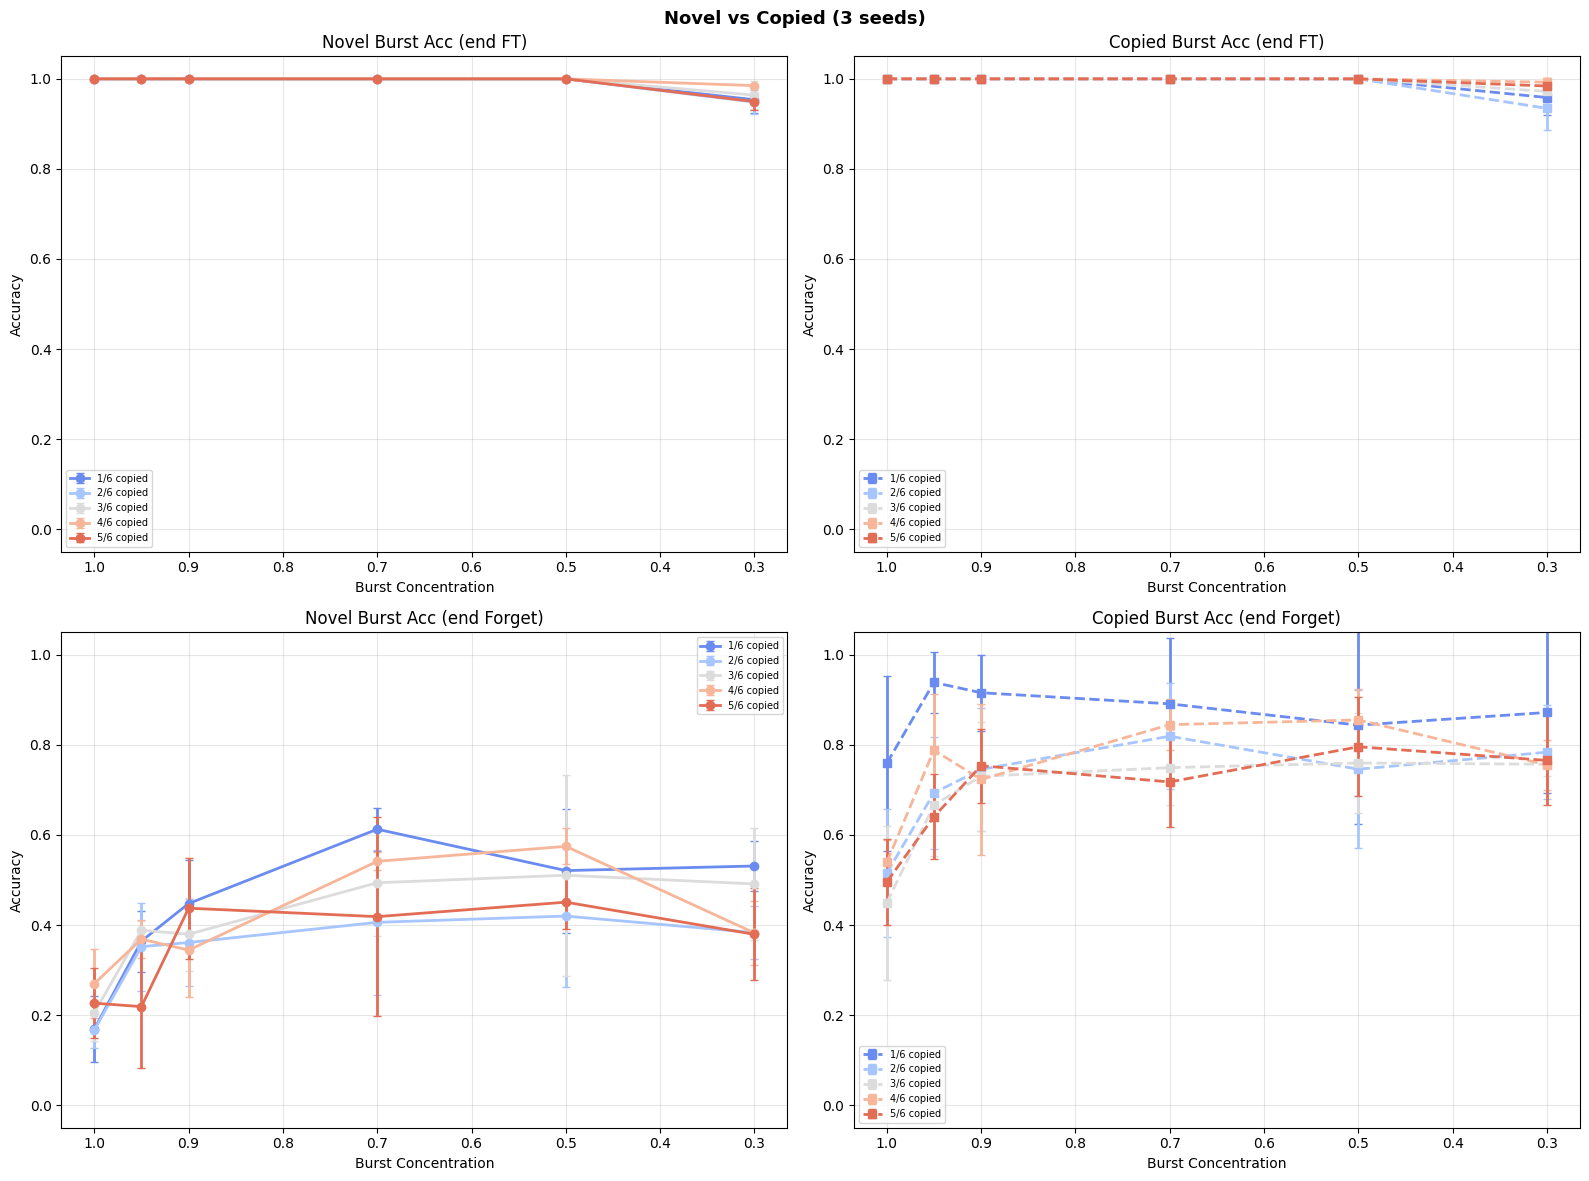

In [9]:
mixed_corrs = [c for c in CORRELATIONS if 0 < c < 1]
if not mixed_corrs:
    print("No mixed correlations")
else:
    corr_colors_mix = plt.cm.coolwarm(np.linspace(0.15, 0.85, len(mixed_corrs)))
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for i_c, corr in enumerate(mixed_corrs):
        c = corr_colors_mix[i_c]
        n_cop = int(round(corr*N_BURST))
        lbl = f"{n_cop}/{N_BURST} copied"
        i_corr = CORRELATIONS.index(corr)
        axes[0,0].errorbar(FRACS, grids_mean["ft_burst_novel_acc"][i_corr],
                           yerr=grids_std["ft_burst_novel_acc"][i_corr],
                           fmt="o-", color=c, label=lbl, linewidth=2, capsize=3)
        axes[0,1].errorbar(FRACS, grids_mean["ft_burst_copied_acc"][i_corr],
                           yerr=grids_std["ft_burst_copied_acc"][i_corr],
                           fmt="s--", color=c, label=lbl, linewidth=2, capsize=3)
        axes[1,0].errorbar(FRACS, grids_mean["fg_burst_novel_acc"][i_corr],
                           yerr=grids_std["fg_burst_novel_acc"][i_corr],
                           fmt="o-", color=c, label=lbl, linewidth=2, capsize=3)
        axes[1,1].errorbar(FRACS, grids_mean["fg_burst_copied_acc"][i_corr],
                           yerr=grids_std["fg_burst_copied_acc"][i_corr],
                           fmt="s--", color=c, label=lbl, linewidth=2, capsize=3)
    for ax in axes.flatten():
        ax.set_xlabel("Burst Concentration"); ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3); ax.invert_xaxis(); ax.set_ylim(-0.05, 1.05)
    axes[0,0].set_title("Novel Burst Acc (end FT)"); axes[0,0].set_ylabel("Accuracy")
    axes[0,1].set_title("Copied Burst Acc (end FT)"); axes[0,1].set_ylabel("Accuracy")
    axes[1,0].set_title("Novel Burst Acc (end Forget)"); axes[1,0].set_ylabel("Accuracy")
    axes[1,1].set_title("Copied Burst Acc (end Forget)"); axes[1,1].set_ylabel("Accuracy")
    fig.suptitle(f"Novel vs Copied ({n_seeds} seeds)", fontsize=13, fontweight="bold")
    fig.tight_layout(); plt.show()

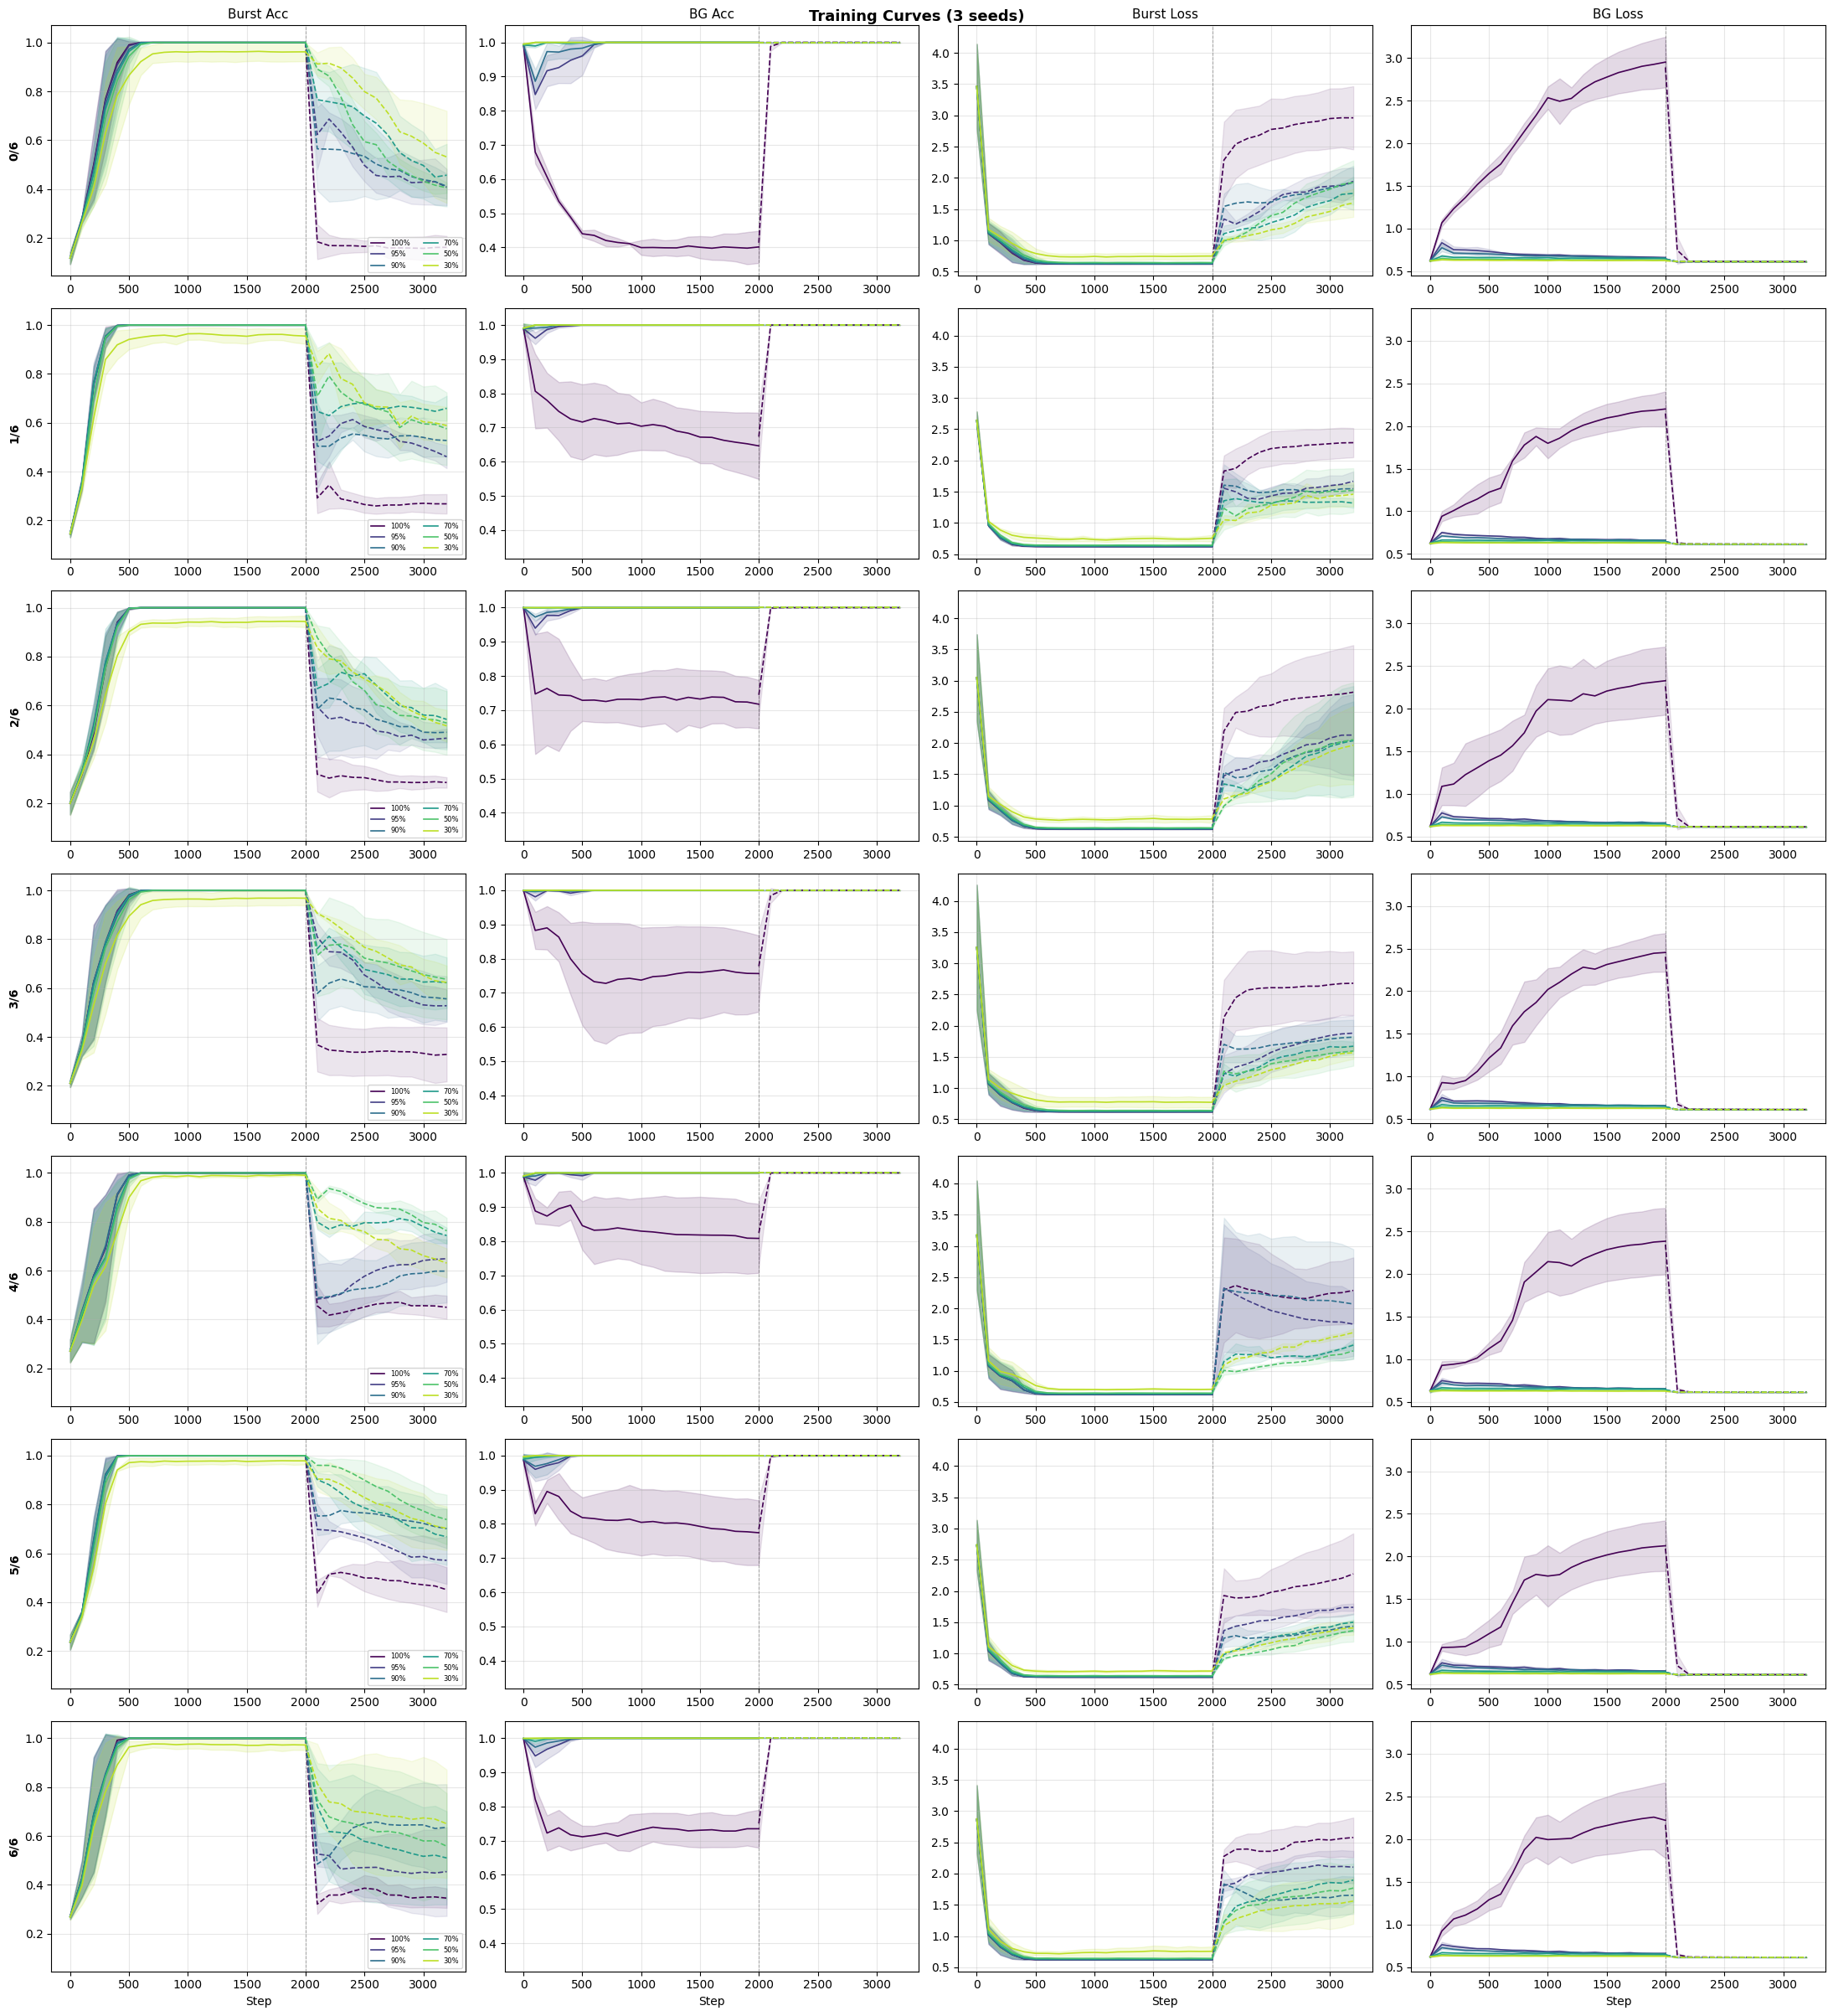

In [10]:
frac_colors = plt.cm.viridis(np.linspace(0, 0.9, n_frac))
fig, axes = plt.subplots(n_corr, 4, figsize=(22, 3.5*n_corr), sharey='col')
if n_corr == 1: axes = axes[np.newaxis, :]
for i_c, corr in enumerate(CORRELATIONS):
    for i_f, frac in enumerate(FRACS):
        c = frac_colors[i_f]; label = f"{int(frac*100)}%"
        valid = [s for s in SEEDS if all_ft[corr][s][i_f] is not None]
        if not valid: continue
        for col, key in enumerate(["acc_burst", "acc_other", "loss_burst", "loss_other"]):
            ax = axes[i_c, col]
            ft_c = [all_ft[corr][s][i_f]["log"][key] for s in valid]
            ft_s = all_ft[corr][valid[0]][i_f]["log"]["step"]
            n = min(len(x) for x in ft_c)
            arr = np.array([x[:n] for x in ft_c])
            ax.plot(ft_s[:n], arr.mean(0), color=c, linewidth=1.2, label=label if col==0 else None)
            ax.fill_between(ft_s[:n], arr.mean(0)-arr.std(0), arr.mean(0)+arr.std(0), color=c, alpha=0.15)
            fg_v = [s for s in valid if all_fg[corr][s][i_f] is not None]
            if fg_v:
                fg_c = [all_fg[corr][s][i_f]["log"][key] for s in fg_v]
                fg_sr = all_fg[corr][fg_v[0]][i_f]["log"]["step"]
                ft_end = ft_s[-1] if ft_s else 0
                nf = min(len(x) for x in fg_c)
                fa = np.array([x[:nf] for x in fg_c])
                fgs = [s+ft_end for s in fg_sr[:nf]]
                ax.plot(fgs, fa.mean(0), color=c, linewidth=1.2, linestyle="--")
                ax.fill_between(fgs, fa.mean(0)-fa.std(0), fa.mean(0)+fa.std(0), color=c, alpha=0.1)
            if i_f==0 and ft_s: ax.axvline(ft_s[-1], color="black", linewidth=0.7, linestyle="--", alpha=0.3)
    n_cop = int(round(corr*N_BURST))
    axes[i_c,0].set_ylabel(f"{n_cop}/{N_BURST}", fontsize=10, fontweight="bold")
    axes[i_c,0].legend(fontsize=6, loc="lower right", ncol=2)
for col, t in enumerate(["Burst Acc", "BG Acc", "Burst Loss", "BG Loss"]):
    axes[0,col].set_title(t, fontsize=11); axes[-1,col].set_xlabel("Step")
    for i_c in range(n_corr): axes[i_c,col].grid(True, alpha=0.3)
fig.suptitle(f"Training Curves ({n_seeds} seeds)", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()